# Original-parameter groups_only_vs_scale (Group-Level Best Response)

Same setup as `GroupsOnly_OriginalParameters.ipynb`,
but individuals base their join/leave decisions on the group's fecundity before and
after the transition (i.e., "group fitness"), rather than comparing to the fecundity
of a solitary individual, W(1).

Therefore, for joining a group of size x-1 to form a group of size x:
$$
S_J(x) = \frac{1}{1 + \exp\left(-\gamma \left(W(x) - W(x-1)\right)\right)}
$$
and for leaving a group of size x to form a group of size x-1:
$$
S_l(x) = \frac{1}{1 + \exp\left(-\gamma \left(W(x-1) - W(x)\right)\right)}
$$
implemented via `fun_S_grouplevel`, `fun_dg_births_givenW_grouplevel!`, and
`get_g_equilibria_givenW_grouplevel` in `CooperativeHuntingPkg`. 

Figures are saved with a `_grouplevel` suffix so they don't overwrite the
individual-fitness-based versions from `GroupsOnly_OriginalParameters.ipynb`.


In [1]:
using Revise
push!(LOAD_PATH, pwd()) # put current directory on path
using CooperativeHuntingPkg
using UnPack, Plots, LaTeXStrings, Measures, DifferentialEquations
using ForwardDiff, LinearAlgebra
default(
    guidefontsize=18,   # controls xlabel, ylabel, title font size
    tickfontsize=12,    # controls axis number labels
    legendfontsize=16,  # controls legend font
    linewidth=3,        # controls default line thickness
    grid = false,        # turns off grid in background
    dpi=600,
    fontfamily="Computer Modern" # font family that matches latex
)


# saving with bif diagrams
bif_fig_path = "../../CH_manuscript/FIgures/BifurcationDiagrams/"
final_fig_path = "../../CH_manuscript/"

param_label_dic = Dict(
    :mass_ratio => L"Benefit Ratio, $b_1/b_2$",
    :s1         => L"Critical group size, $s$",
    :α1_of_1 => L"Capture Prob. of Solitaries, $\alpha_1(1)$"
)

Dict{Symbol, LaTeXString} with 3 entries:
  :α1_of_1    => L"Capture Prob. of Solitaries, $\alpha_1(1)$"
  :s1         => L"Critical group size, $s$"
  :mass_ratio => L"Benefit Ratio, $b_1/b_2$"

In [2]:
# Base parameters in original (dimensional) units.
# a_i: attack rate, b_i: prey-to-predator conversion, h_ia/h_ib: handling time components.
# M1, M2: prey population sizes (in original density units).
# mass_ratio = b2/b1 = (h2a+h2b)/(h1a+h1b); b1 and h1b are derived from it.
params_base_orig = Dict{Symbol,Any}(
    :α1_of_1  => 0.05,    # capture prob of big prey by singleton
    :α2_of_1  => 1.0,    # capture prob of small prey (constant)
    :s1       => 2.0,     # group size where α1(x) = 0.5
    :a1       => 1.0,     # attack rate on big prey
    :a2       => 0.5,     # attack rate on small prey
    :b2       => 0.01,     # conversion rate for small prey
    :h1a      => 0.0,     # group-size-independent handling time, big prey
    :h2a      => 0.0,     # group-size-independent handling time, small prey
    :h2b      => 0.02,     # solo handling time (group-splittable) for small prey
    :mass_ratio => 5.0,   # m2/m1 = b2/b1; b1 and h1b derived from this
    :M1       => 80.0,    # big prey population density
    :M2       => 50.0,     # small prey population density
    :d        => 100.0,   # steepness of join/leave best-response function
    :x_max    => 15,
    :P        => 15.0,
    :Tg       => 0.01
)
# Derive b1 and h1b at the default mass_ratio
scale_parameters_orig(params_base_orig)

Dict{Symbol, Any} with 18 entries:
  :α1_of_1    => 0.05
  :a2         => 0.5
  :Tg         => 0.01
  :d          => 100.0
  :b2         => 0.01
  :s1         => 2.0
  :mass_ratio => 5.0
  :h1b        => 0.1
  :P          => 15.0
  :M1         => 80.0
  :α2_of_1    => 1.0
  :h2b        => 0.02
  :x_max      => 15
  :h1a        => 0.0
  :h2a        => 0.0
  :M2         => 50.0
  :b1         => 0.05
  :a1         => 1.0

In [ ]:
# Equilibrium heatmap vs mass_ratio (group-level best response)
paramkey  = :mass_ratio
paramvec  = collect(1.01:0.004:5.0)   # mass_ratio 0.1→1.0

dg_fun_gl = fun_dg_births_givenW_grouplevel!
eq_fun_gl = get_g_equilibria_givenW_grouplevel

# normal
hm1, λ1 = make_hm_versus_param_solve_g(
    paramkey, paramvec, params_base_orig; 
    offsets = [0.8,-0.3,0.5], # offsets = [mangel clark offset, mean experienced offset, optimal W offset]
    dg_fun = dg_fun_gl, equilibria_fun = eq_fun_gl
    )

# suppress leaving and pairing
params = deepcopy(params_base_orig)
params[:fuse_param] = 0.01
params[:leave_param] = 0.01
hm2, λ2 = make_hm_versus_param_solve_g(paramkey, paramvec, params; dg_fun = dg_fun_gl, equilibria_fun = eq_fun_gl)

## Add Births
methods(make_hm_versus_param_solve_g)
params_births = deepcopy(params_base_orig)
params_births[:allow_births] = 1
hm3, λ3 = make_hm_versus_param_solve_g(paramkey, paramvec, params_births; dg_fun = dg_fun_gl, equilibria_fun = eq_fun_gl)

# births with suppression of leaving and pairing
params_births = deepcopy(params_base_orig)
params_births[:allow_births] = 1
params_births[:fuse_param] = 0.01
params_births[:leave_param] = 0.01
hm4, λ4 = make_hm_versus_param_solve_g(paramkey, paramvec, params_births; dg_fun = dg_fun_gl, equilibria_fun = eq_fun_gl)


┌ Warning: Using arrays or dicts to store parameters of different types can hurt performance.
│ Consider using tuples instead.
└ @ SciMLBase ~/.julia/packages/SciMLBase/YE7xF/src/performance_warnings.jl:33


(Plot{Plots.GRBackend() n=4}, [-0.0783652828715328, -0.07801905009739869, -0.07768565507868588, -0.07736490310470646, -0.07705659741321001, -0.0767605394766977, -0.076476529280058, -0.0762043655894631, -0.07594384621224697, -0.07569476824740394  …  -0.1467191338489846, -0.14671909495700408, -0.14671901210933136, -0.1467188855173861, -0.14671871539179834, -0.1467185019424169, -0.14671824537824527, -0.14671794590760567, -0.14671760373795065, -0.14671721907598206])

In [ ]:
for λ in [λ1, λ2, λ3, λ4]
    println("Number of unstable equilibria is ", sum(λ .> 0))
end

Number of unstable equilibria is 0
Number of unstable equilibria is 0
Number of unstable equilibria is 0
Number of unstable equilibria is 0


In [ ]:
# suppress leaving but not pairing
params = deepcopy(params_base_orig)
params[:fuse_param] = 1.0
params[:leave_param] = 0.01
hm5, λ5 = make_hm_versus_param_solve_g(paramkey, paramvec, params; dg_fun = dg_fun_gl, equilibria_fun = eq_fun_gl)

# suppress pairing but not leaving
params = deepcopy(params_base_orig)
params[:fuse_param] = 0.01
params[:leave_param] = 1.0
hm6, λ6 = make_hm_versus_param_solve_g(paramkey, paramvec, params; dg_fun = dg_fun_gl, equilibria_fun = eq_fun_gl)

# births with suppression of leaving but not pairing
params_births = deepcopy(params_base_orig)
params_births[:allow_births] = 1
params_births[:fuse_param] = 1.0
params_births[:leave_param] = 0.01
hm7, λ7 = make_hm_versus_param_solve_g(paramkey, paramvec, params_births; dg_fun = dg_fun_gl, equilibria_fun = eq_fun_gl)

# births with suppression of pairing but not leaving
params_births = deepcopy(params_base_orig)
params_births[:allow_births] = 1
params_births[:fuse_param] = 0.01
params_births[:leave_param] = 1.0
hm8, λ8 = make_hm_versus_param_solve_g(paramkey, paramvec, params_births; dg_fun = dg_fun_gl, equilibria_fun = eq_fun_gl)


(Plot{Plots.GRBackend() n=4}, [-28.933443876304707, -28.735085665234497, -28.536419509380348, -28.33750303818546, -28.138392723204742, -27.939143856053136, -27.739810529258037, -27.54044561991271, -27.341100775995745, -27.141826405261018  …  -3.0515934593288527, -3.0519394496159165, -3.052285356799102, -3.0526311798288304, -3.05297691766371, -3.0533225692688775, -3.0536681336223612, -3.054013609705932, -3.0543589965135345, -3.054704293043483])

In [ ]:
for λ in [λ5, λ6, λ7, λ8]
    println("Number of unstable equilibria is ", sum(λ .> 0))
end

Number of unstable equilibria is 0
Number of unstable equilibria is 0
Number of unstable equilibria is 0
Number of unstable equilibria is 0


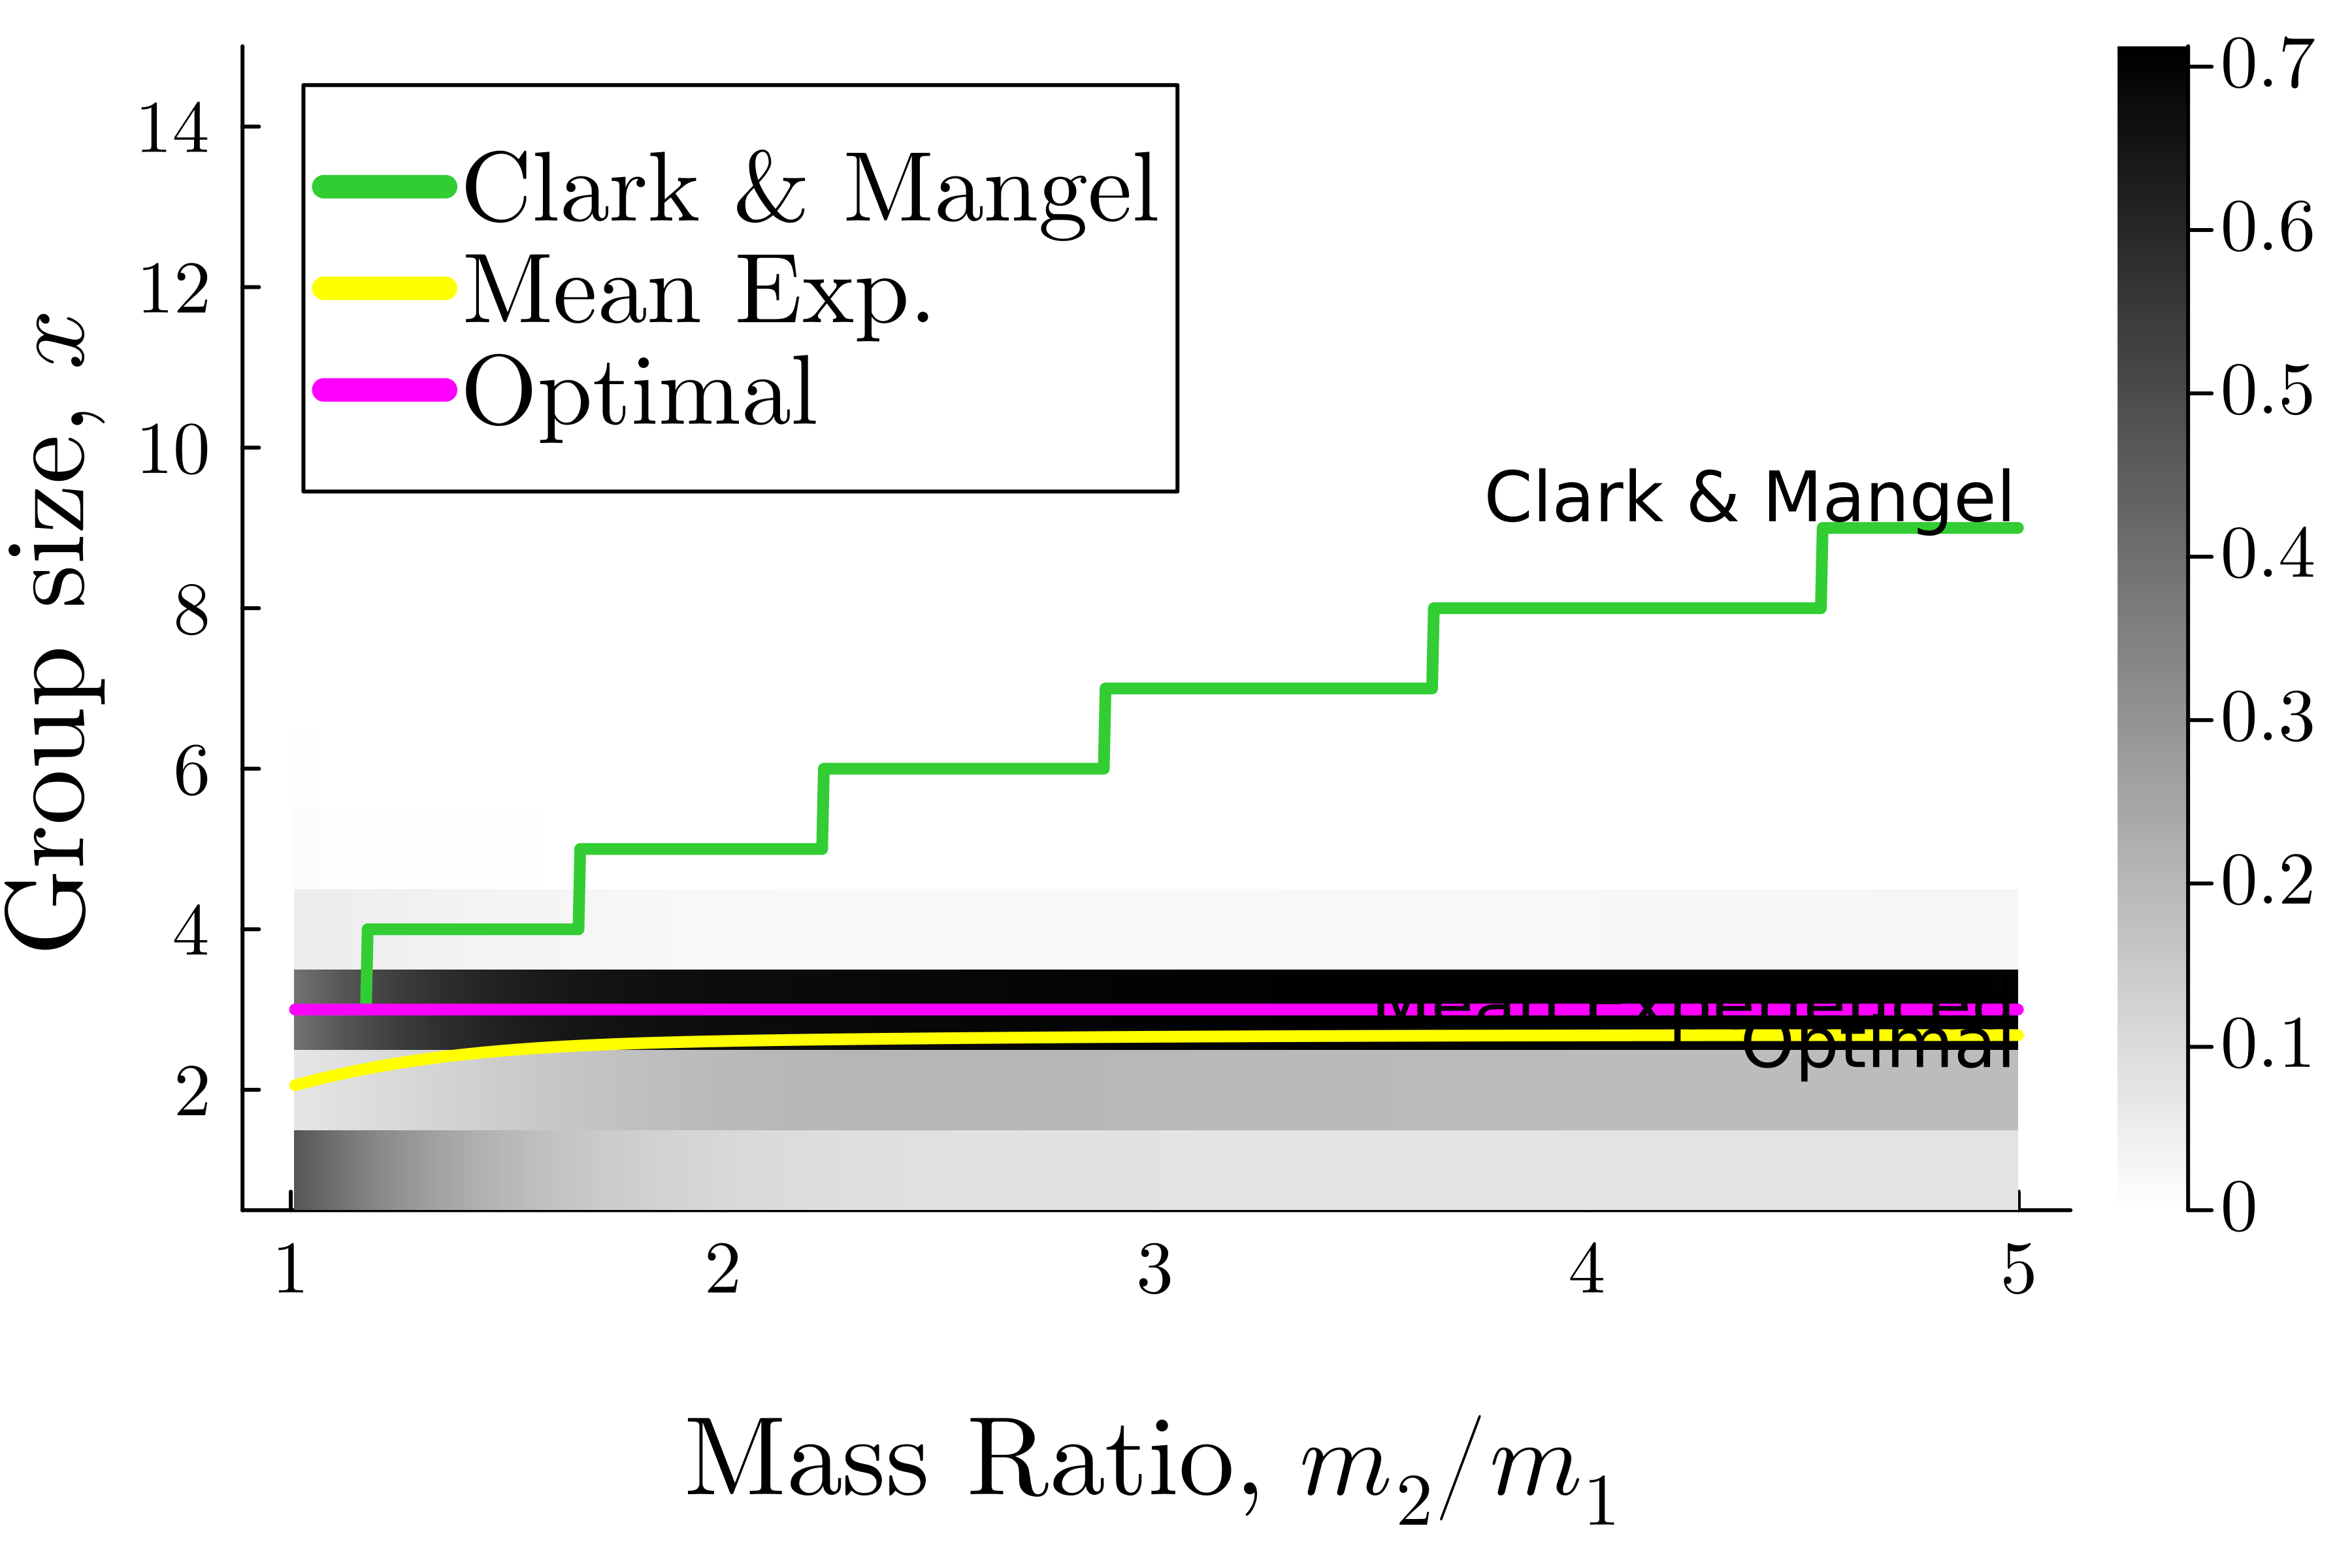

In [ ]:
hm1
plot!(ylims=[0.5,15])

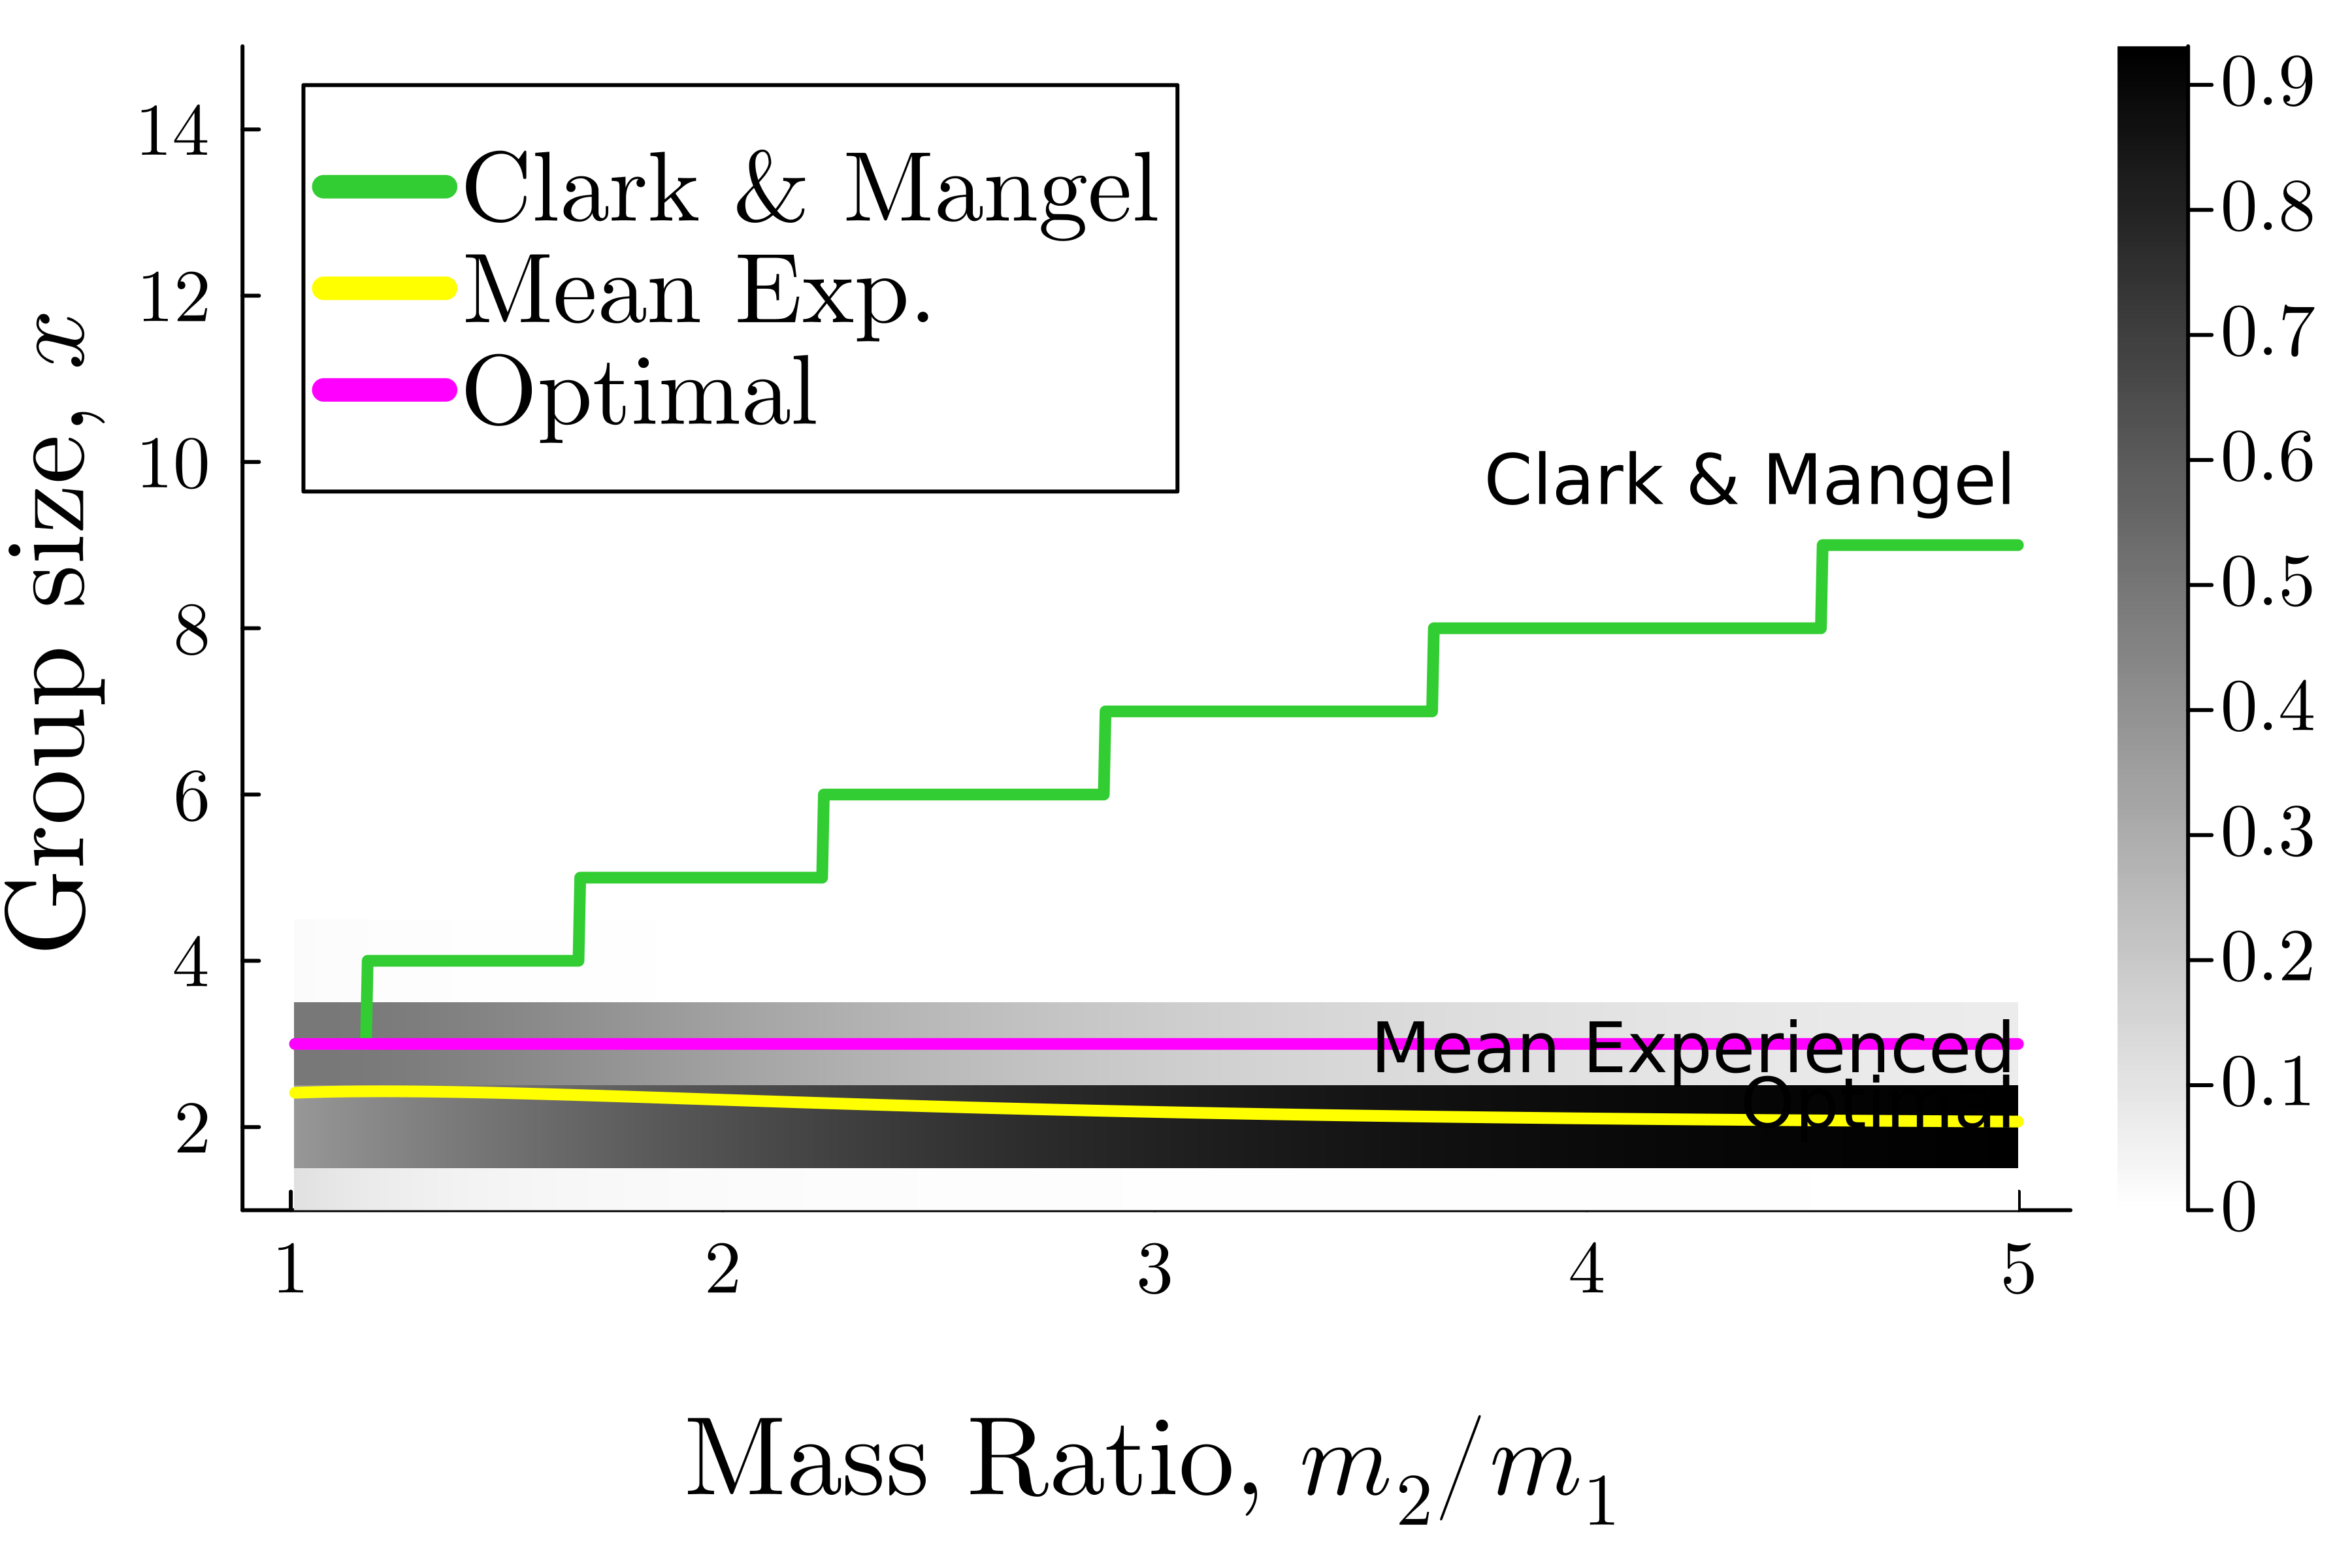

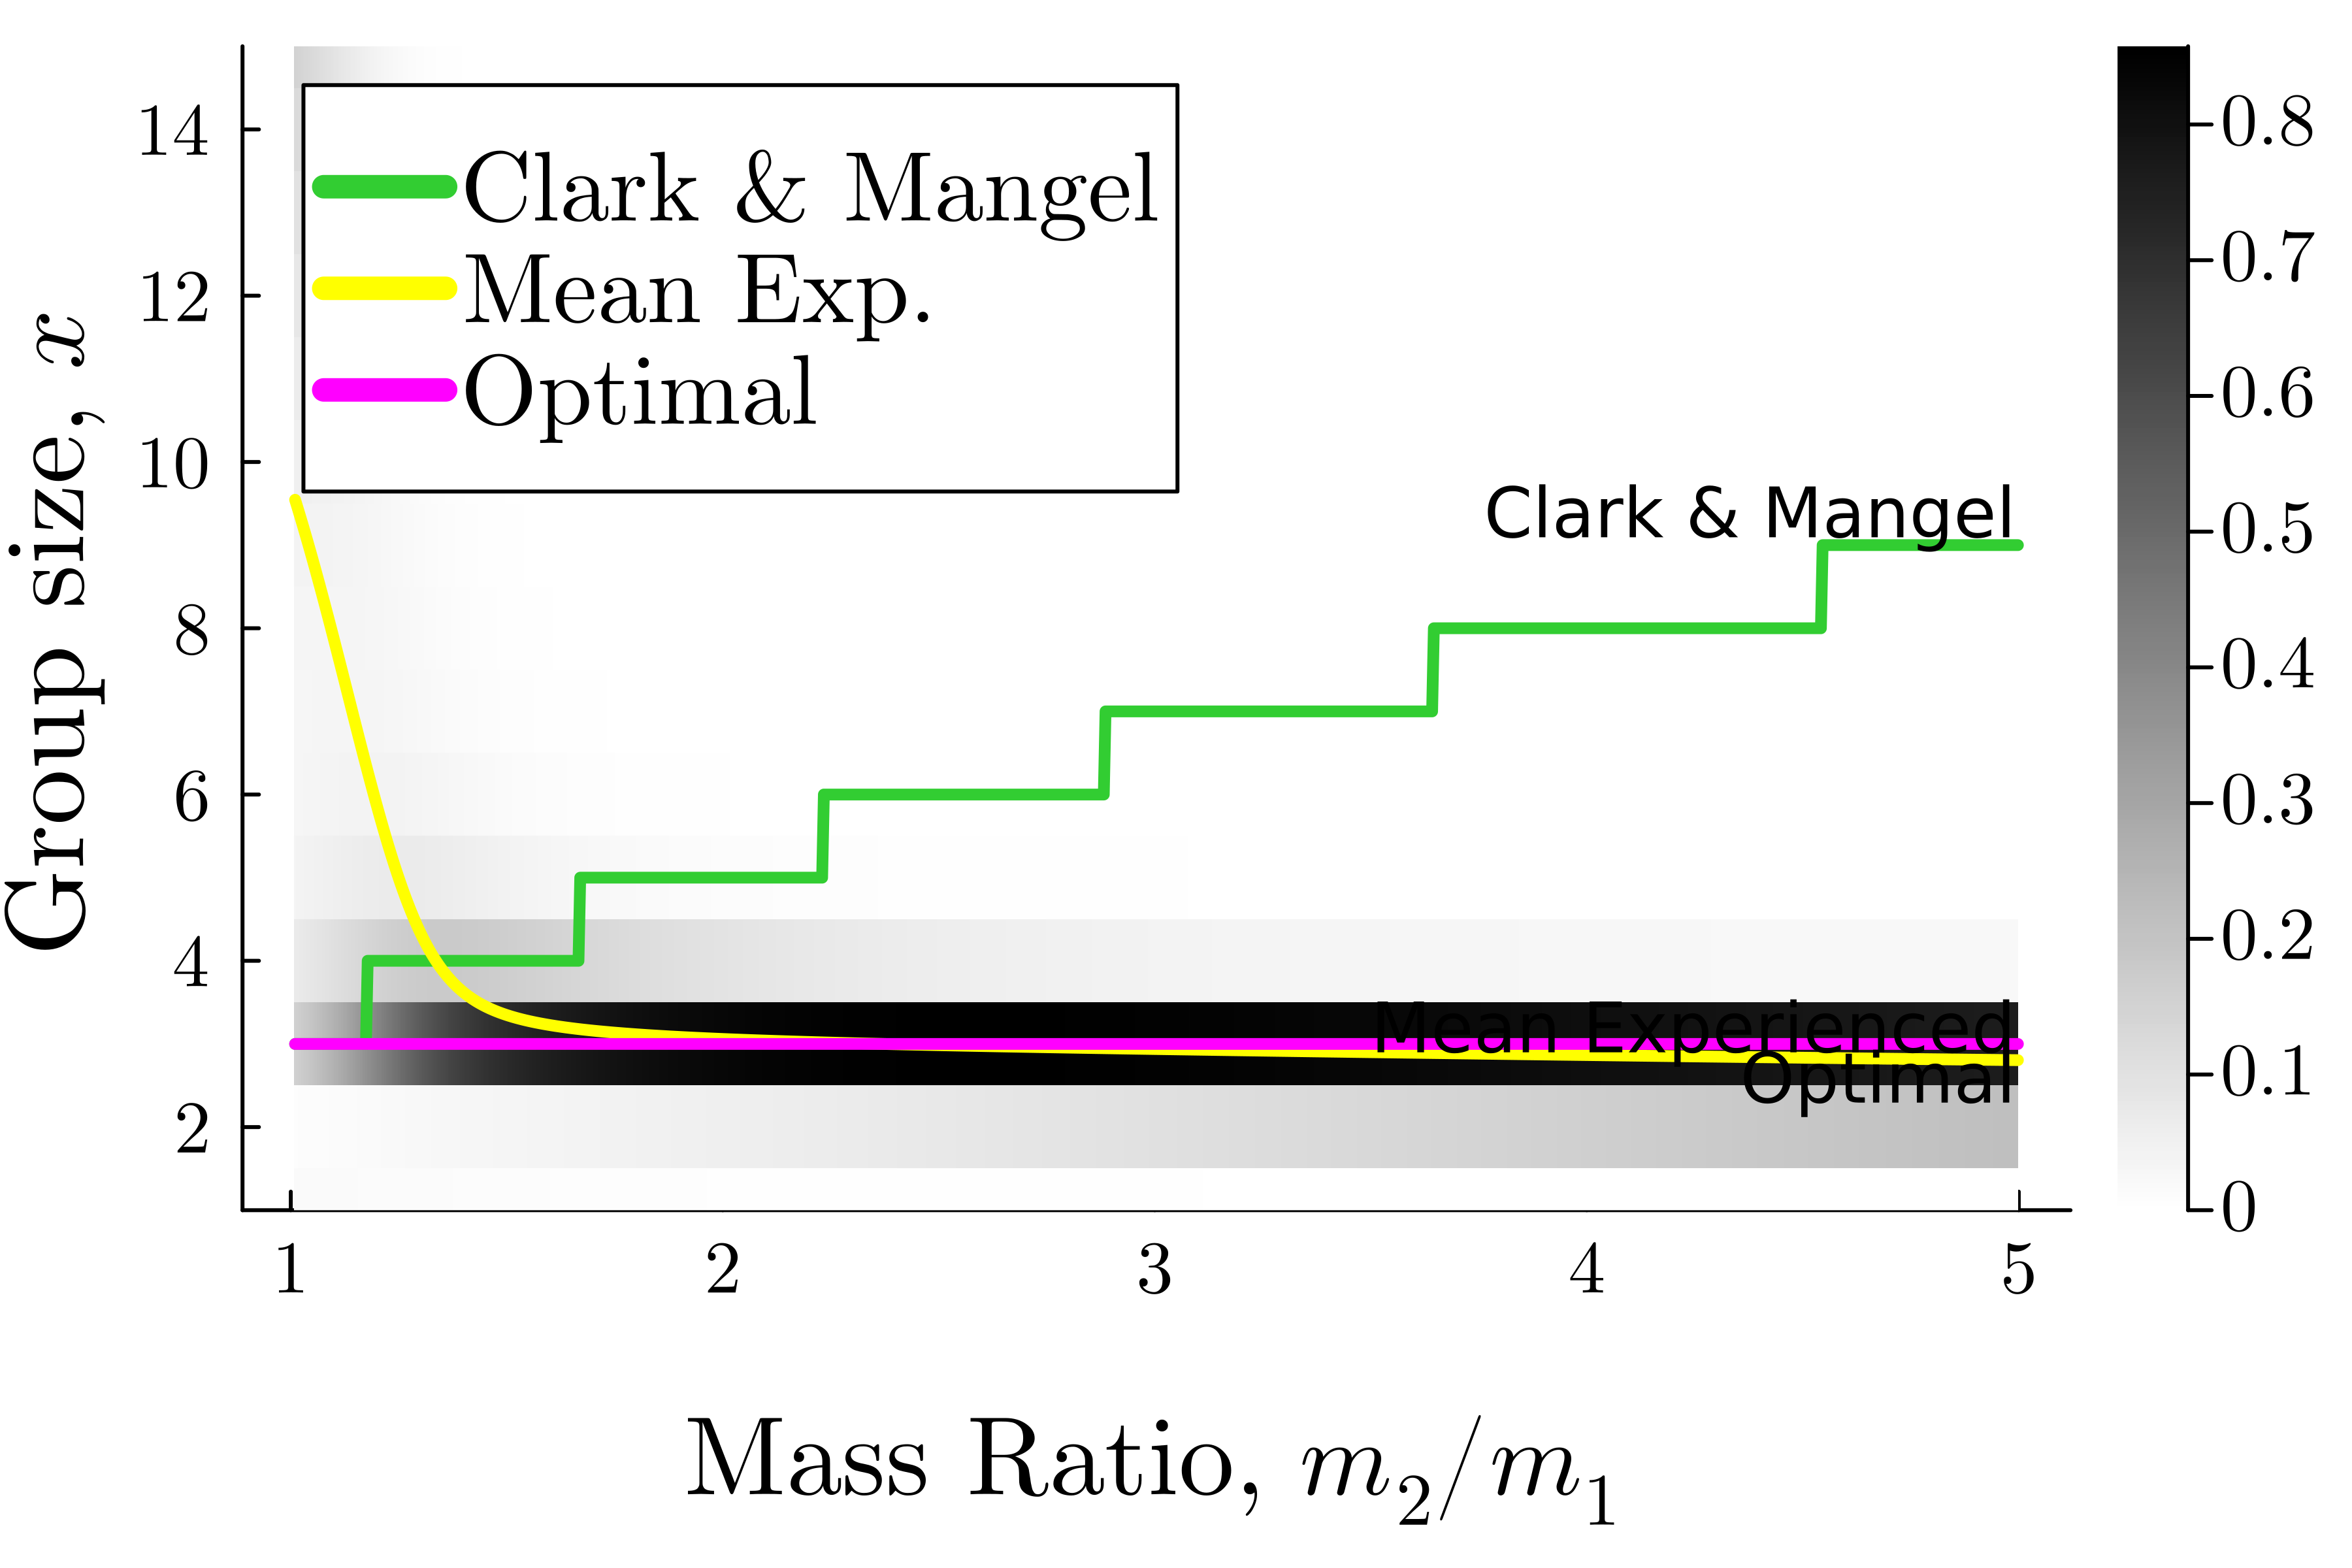

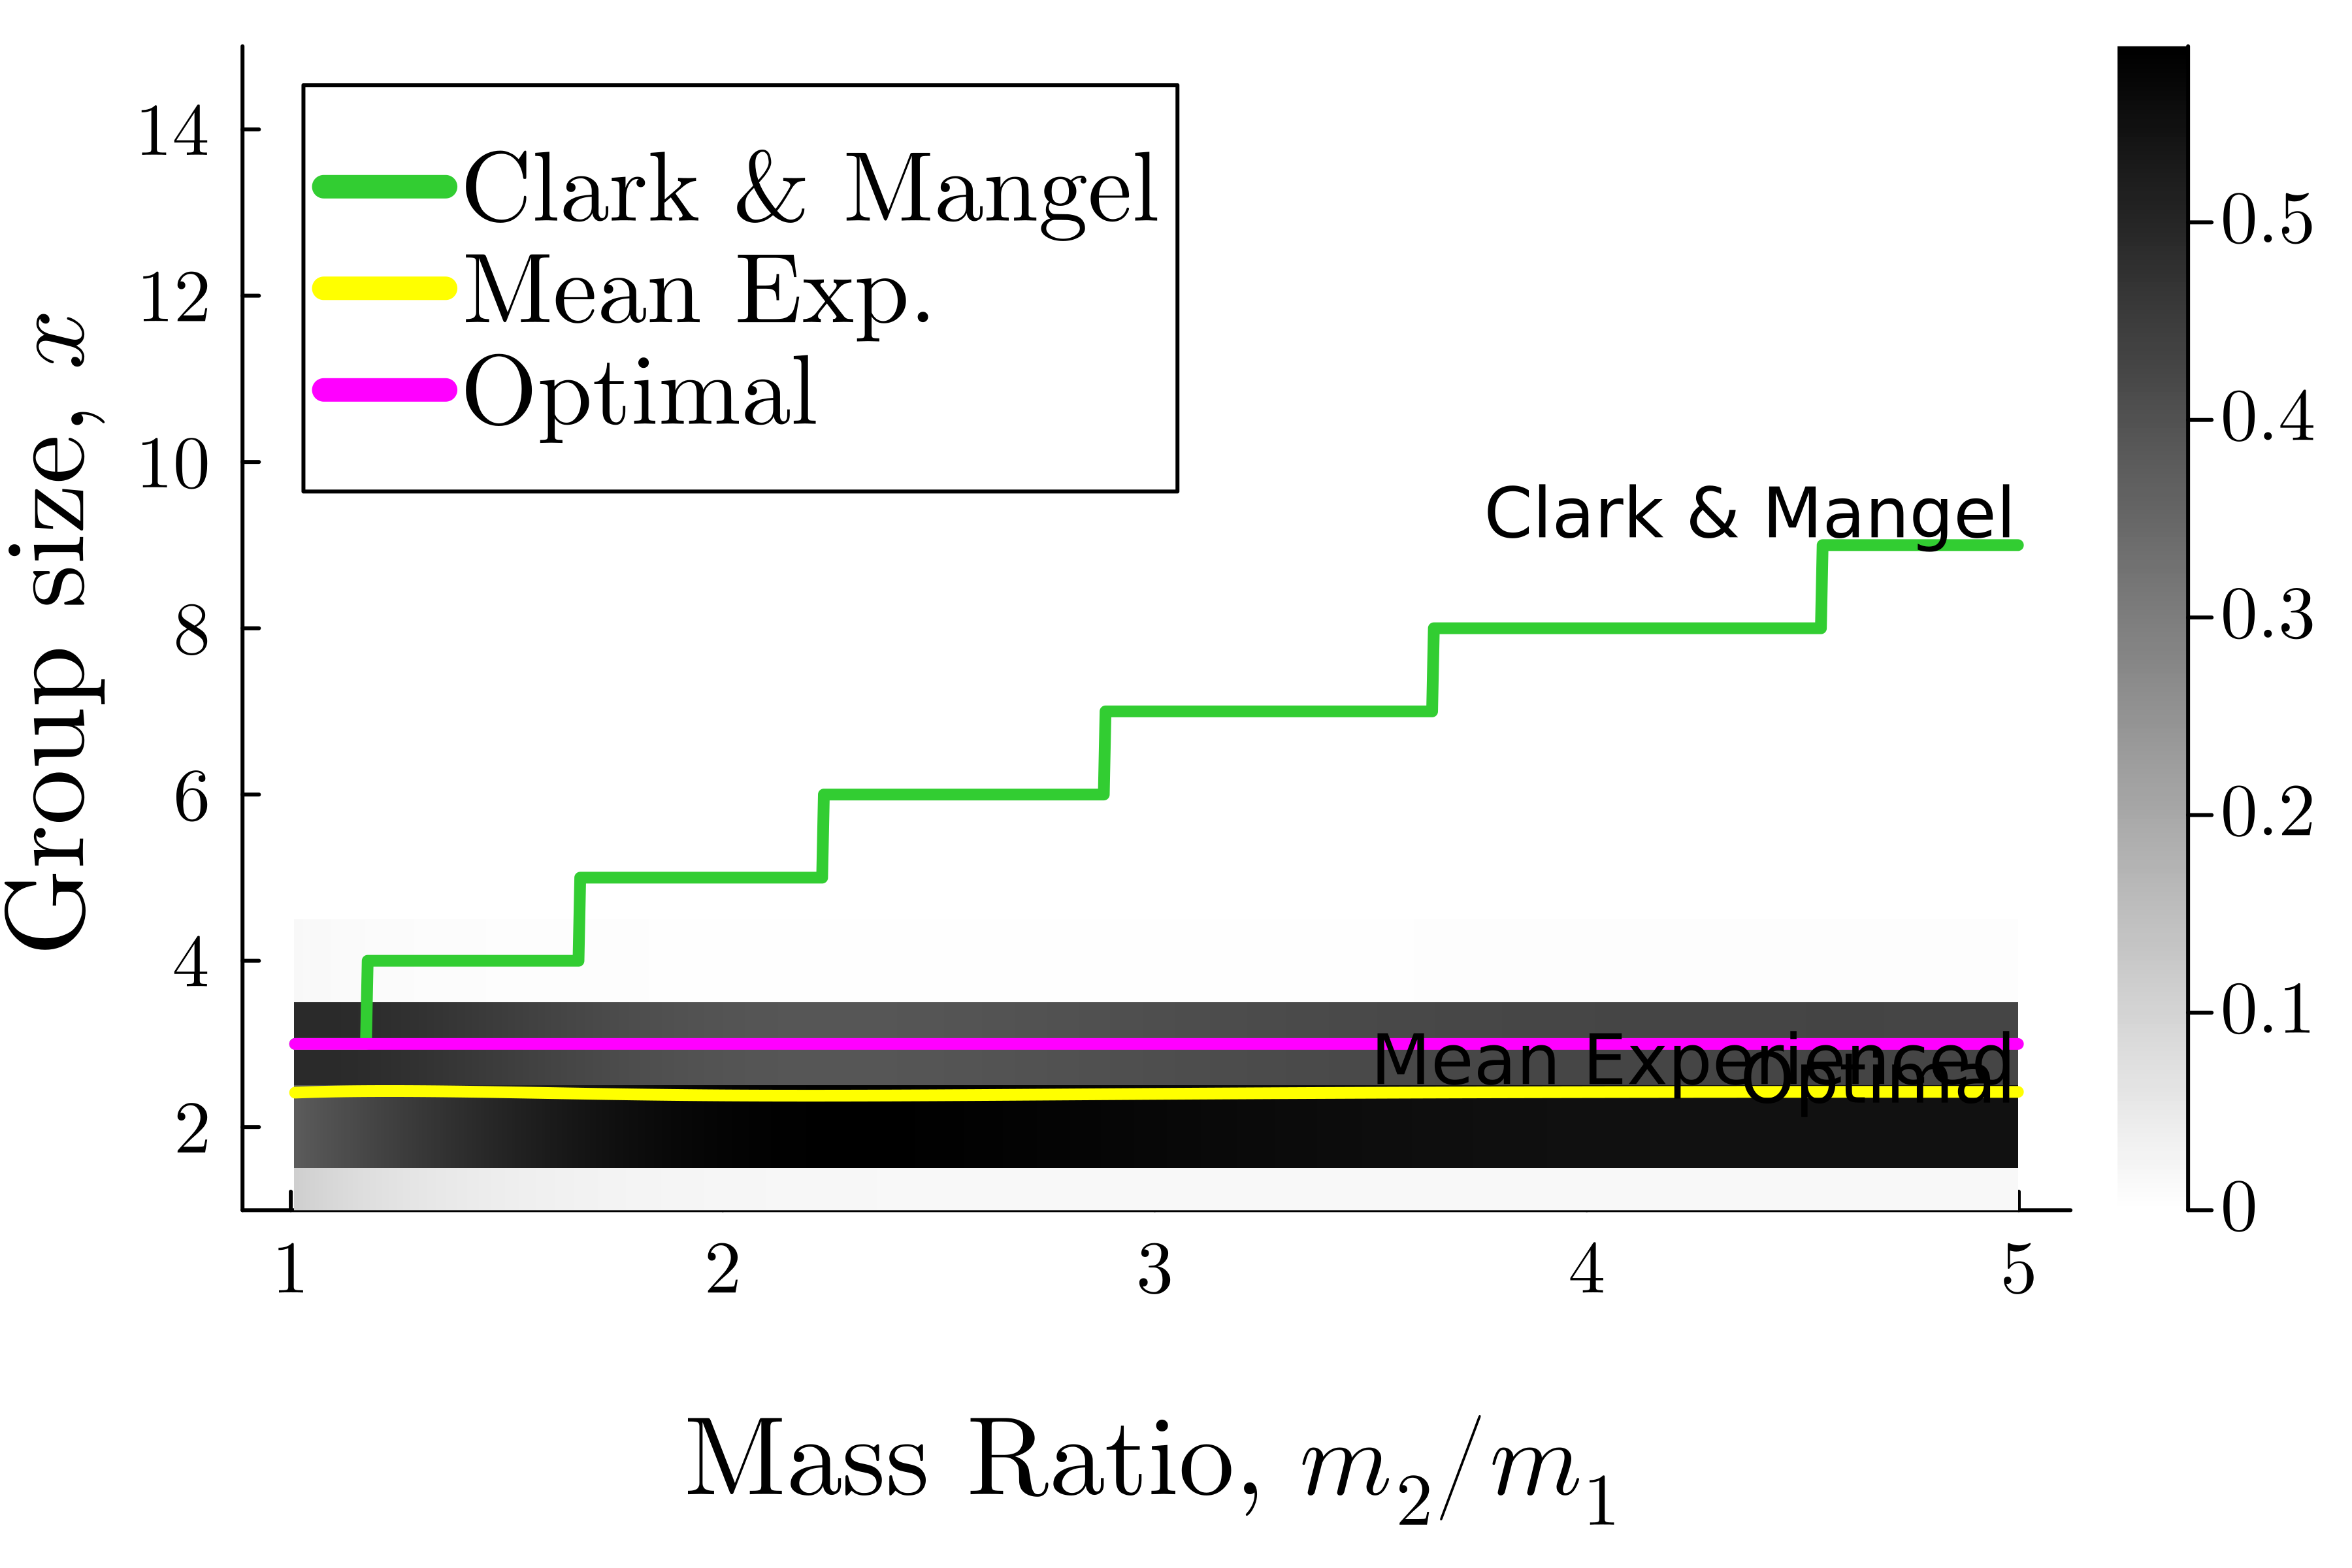

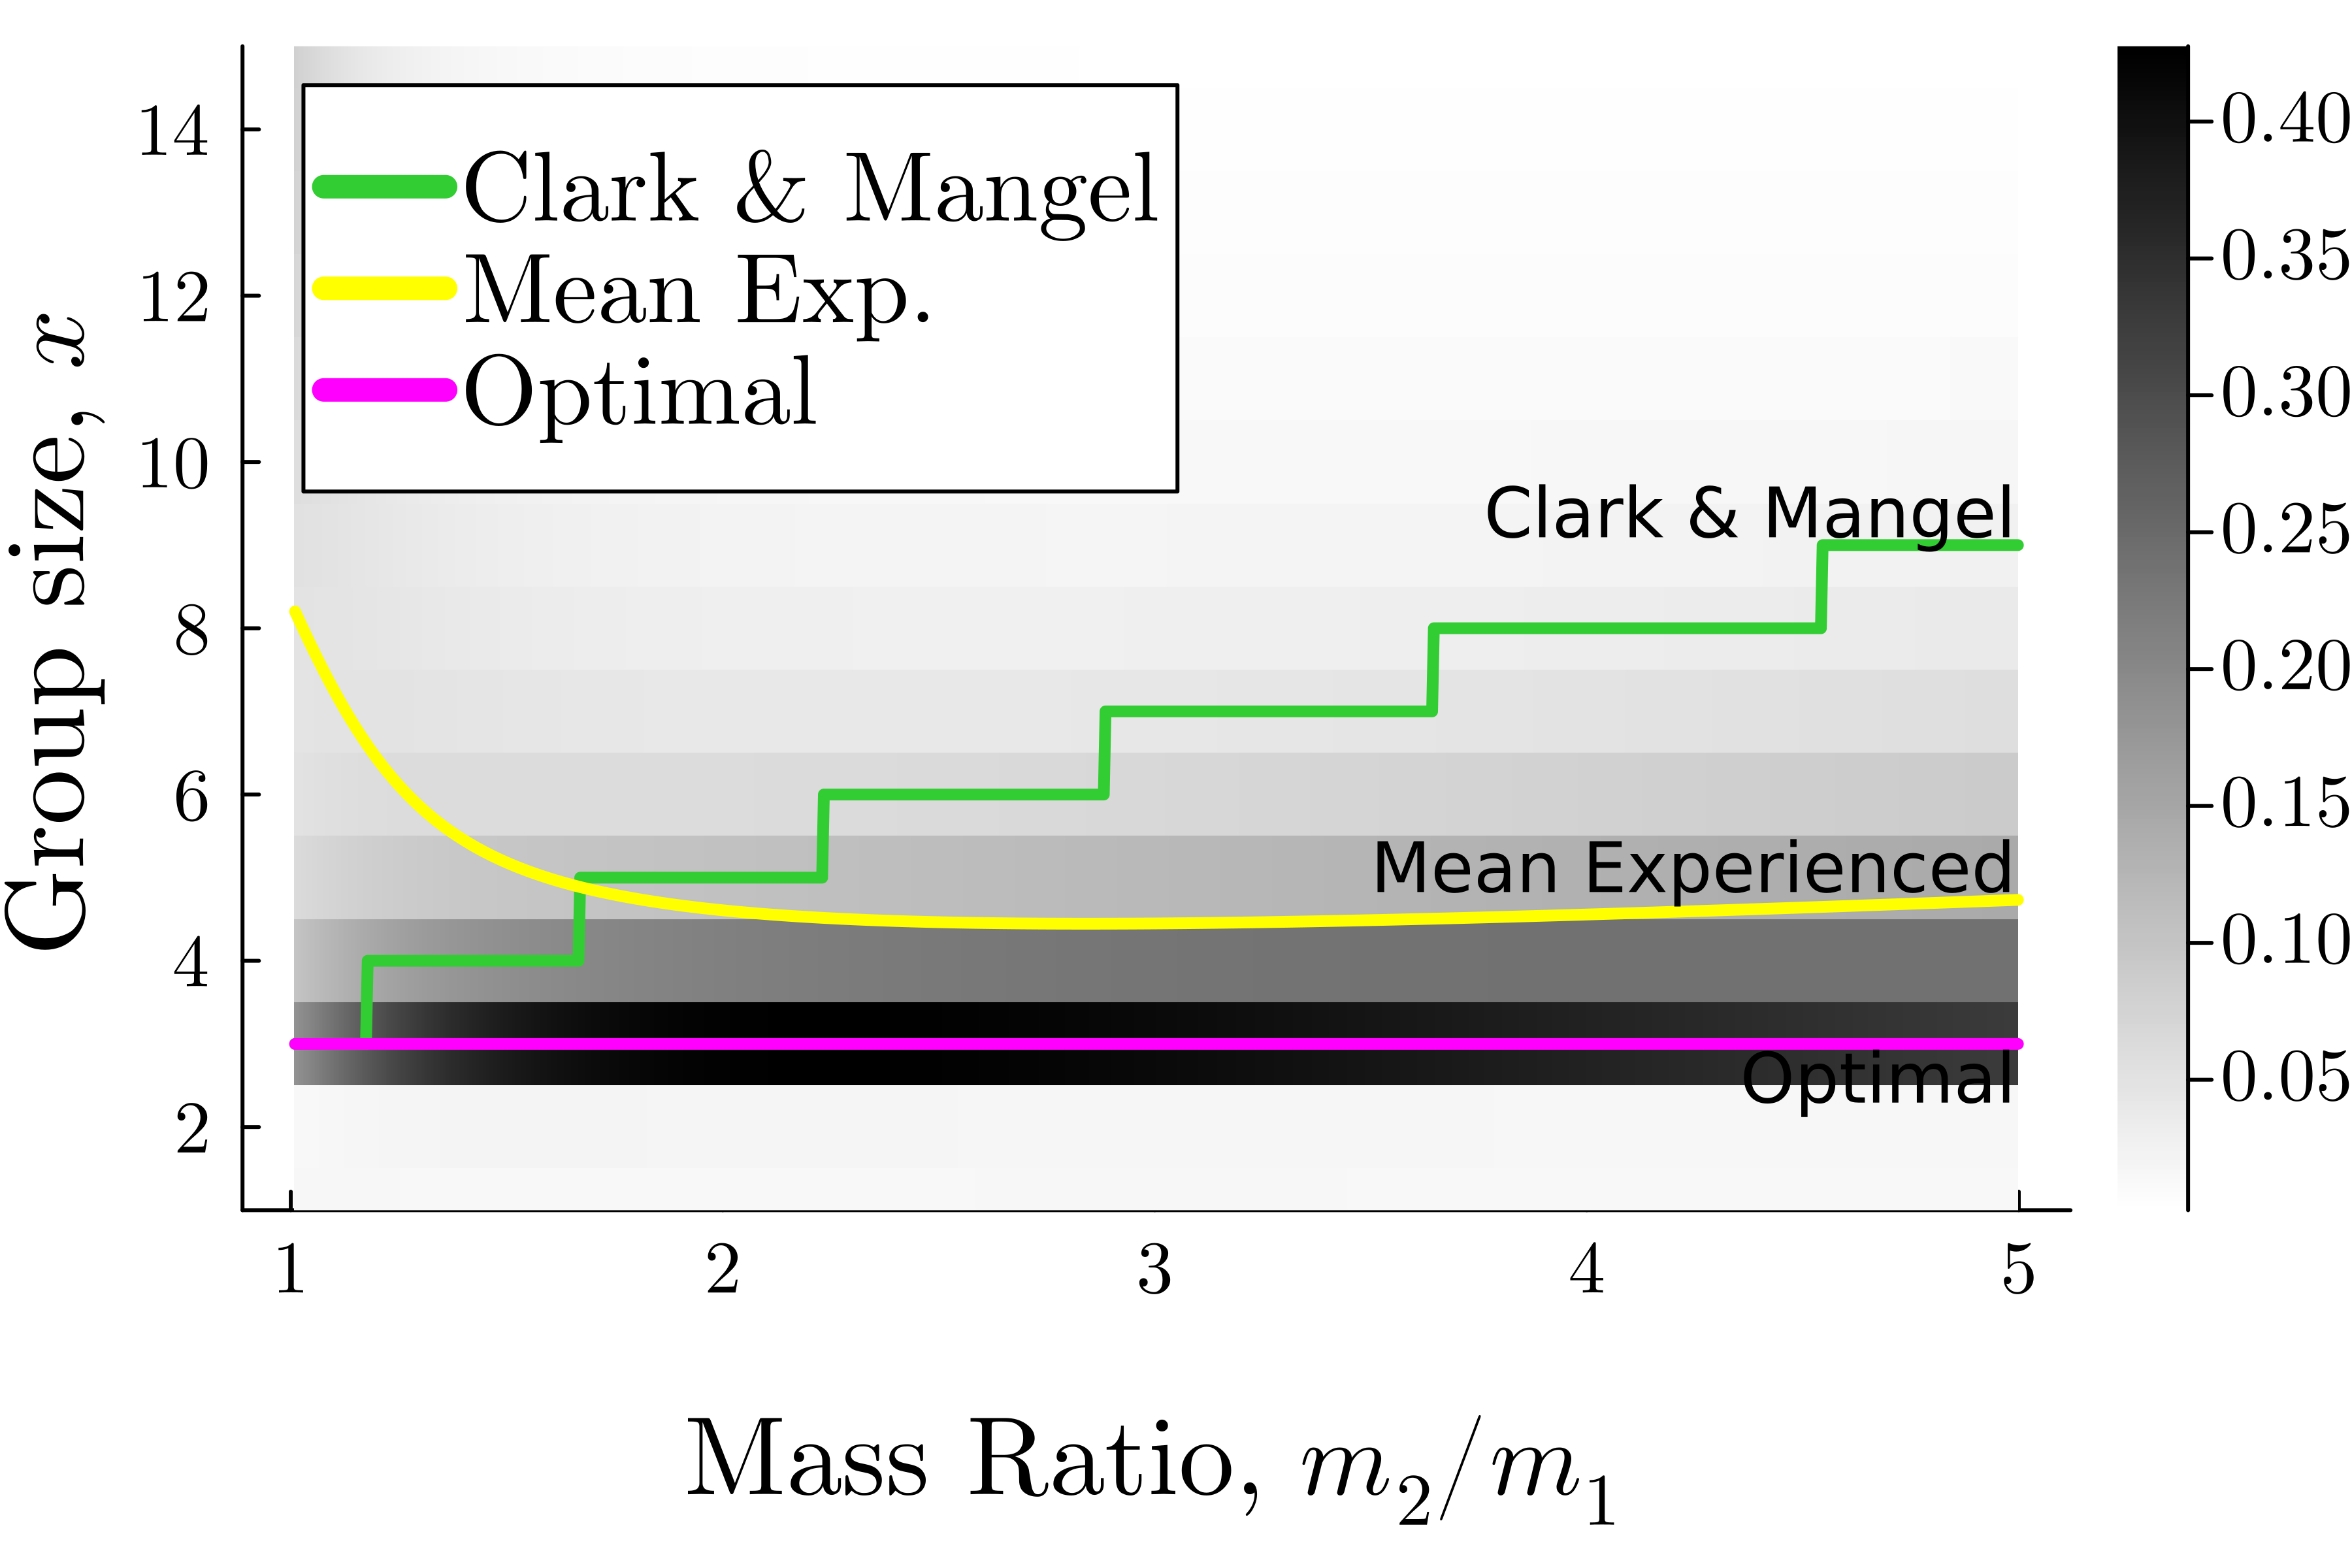

In [ ]:
for hm in [hm1, hm2, hm3, hm4]
    display(hm)
end

In [ ]:
for hm in [hm5, hm6, hm7, hm8]
    display(hm)
end

## Save hm1 (leaving adn pairing unsuppressed)

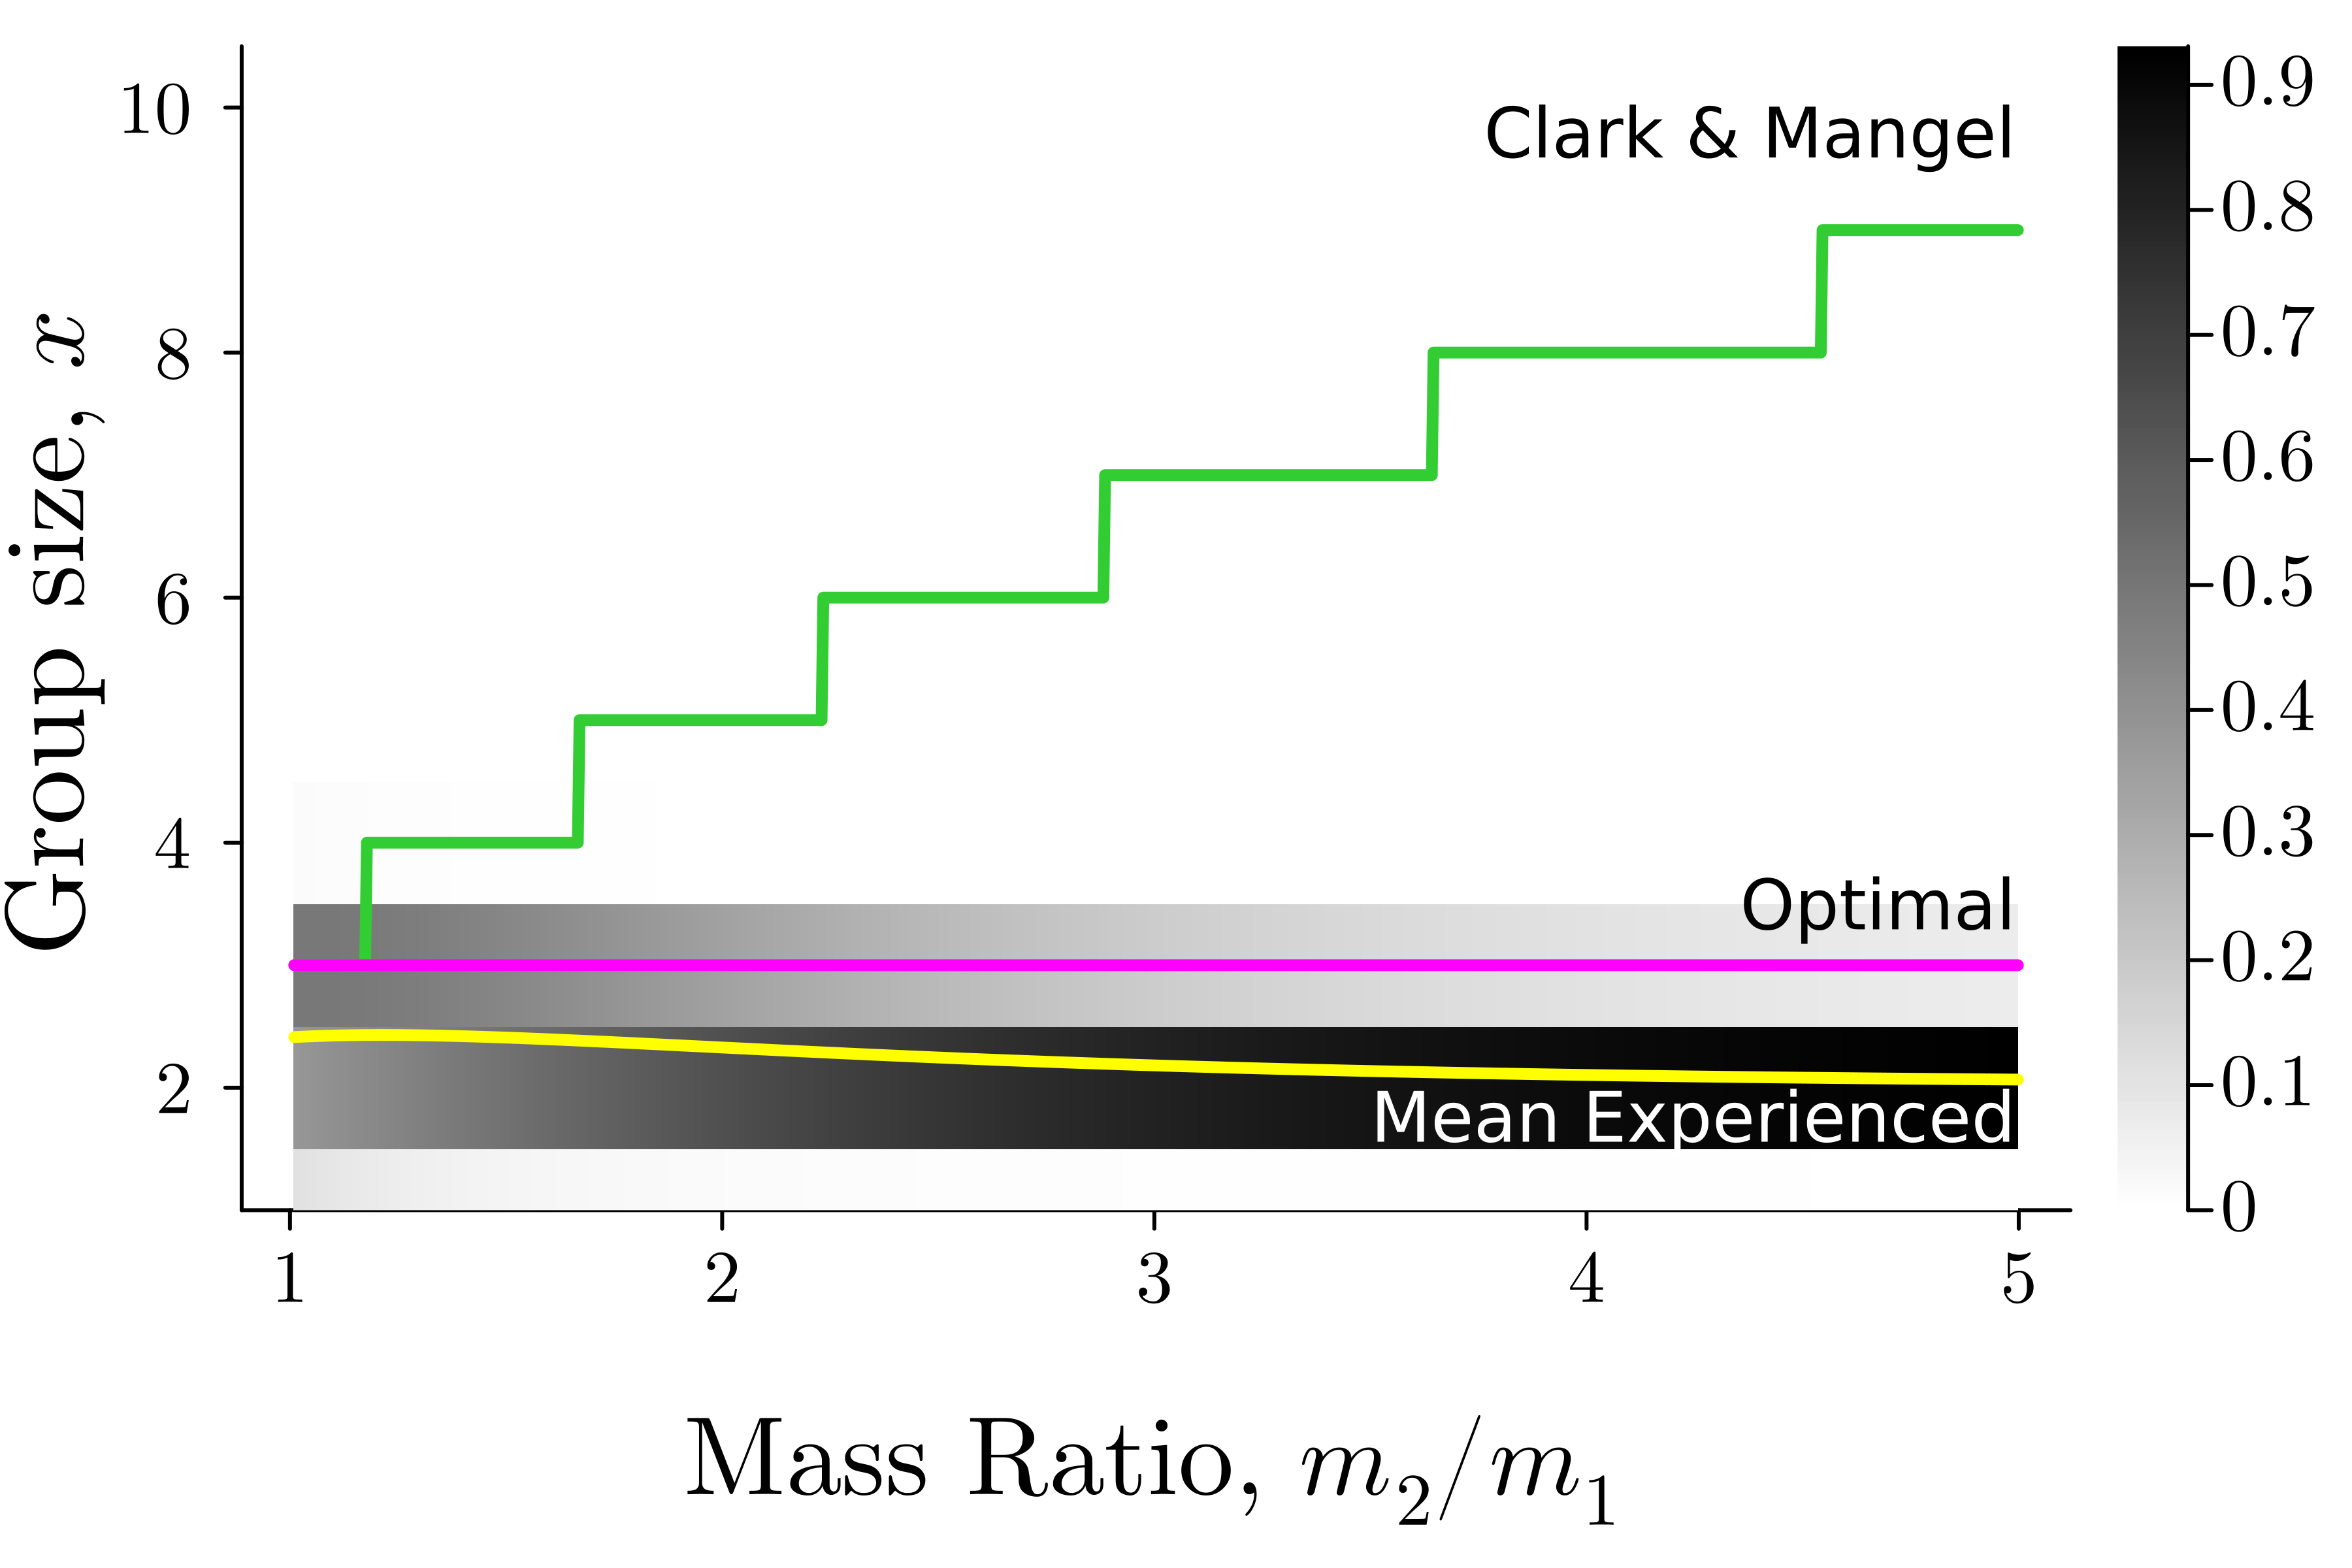

In [ ]:
# normal
hm1
plot!(hm1, legend=false, tick_direction = :out, ylim = [1,10.5])
anns = hm1.subplots[1][:annotations]
x2, y2, _ = anns[2]                      # grab the position of "Mean Experienced"
anns[2] = (x2, y2, text("Mean Experienced", :white, :right, 12))
#savefig(hm1, final_fig_path*"equilibria_only_groups_vs_ratio_grouplevel.pdf")

display(hm1)


## Save all combinations of leaving/pairing suppressed

In [28]:
using Measures

clims = (0.0, 0.7)

# remove annotations of all panels except first one
for hm in [hm1, hm2, hm3, hm4]
    hm.subplots[1][:annotations] = []
end

p1 = plot( 
    plot(hm1; xlab = "", legend = true),
    plot(hm2; xlab = "", ylab = "", right_margin = 5mm, legend=false), #suppress leaving and pairing
    plot(hm3; legend=false), 
    plot(hm4; ylab = "", legend = false); 
    clims = clims, colorbar = false,
    title = ["(A)\n" "(B)" "(C)\n" "(D)"], titlelocation = :left,
    titlefonthalign = :left,
    ylims = (0.5,10.5),
    legendfontsize = 12,
    tick_direction = :out
    )
p_cb = heatmap(fill(NaN, 2, 2); clims, c = cgrad([:white, :black], 256), colorbar=:right,
               framestyle=:none, ticks=false)
#plot!(hm1; legend = true)
p_full = plot(
    p1, p_cb; layout = grid(1, 2, widths=[0.94, 0.06]), size=(1080, 540), 
    bottom_margin = 8mm, left_margin = 5mm, legendfontsize=10
    )

savefig(p_full, final_fig_path * "4heatmaps_ratio_orig_grouplevel.pdf")



GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT


"/Users/taliaborofsky/Documents/Postdoc/Collaborations/CH_GroupFormation/CH_manuscript/4heatmaps_ratio_orig_grouplevel.pdf"

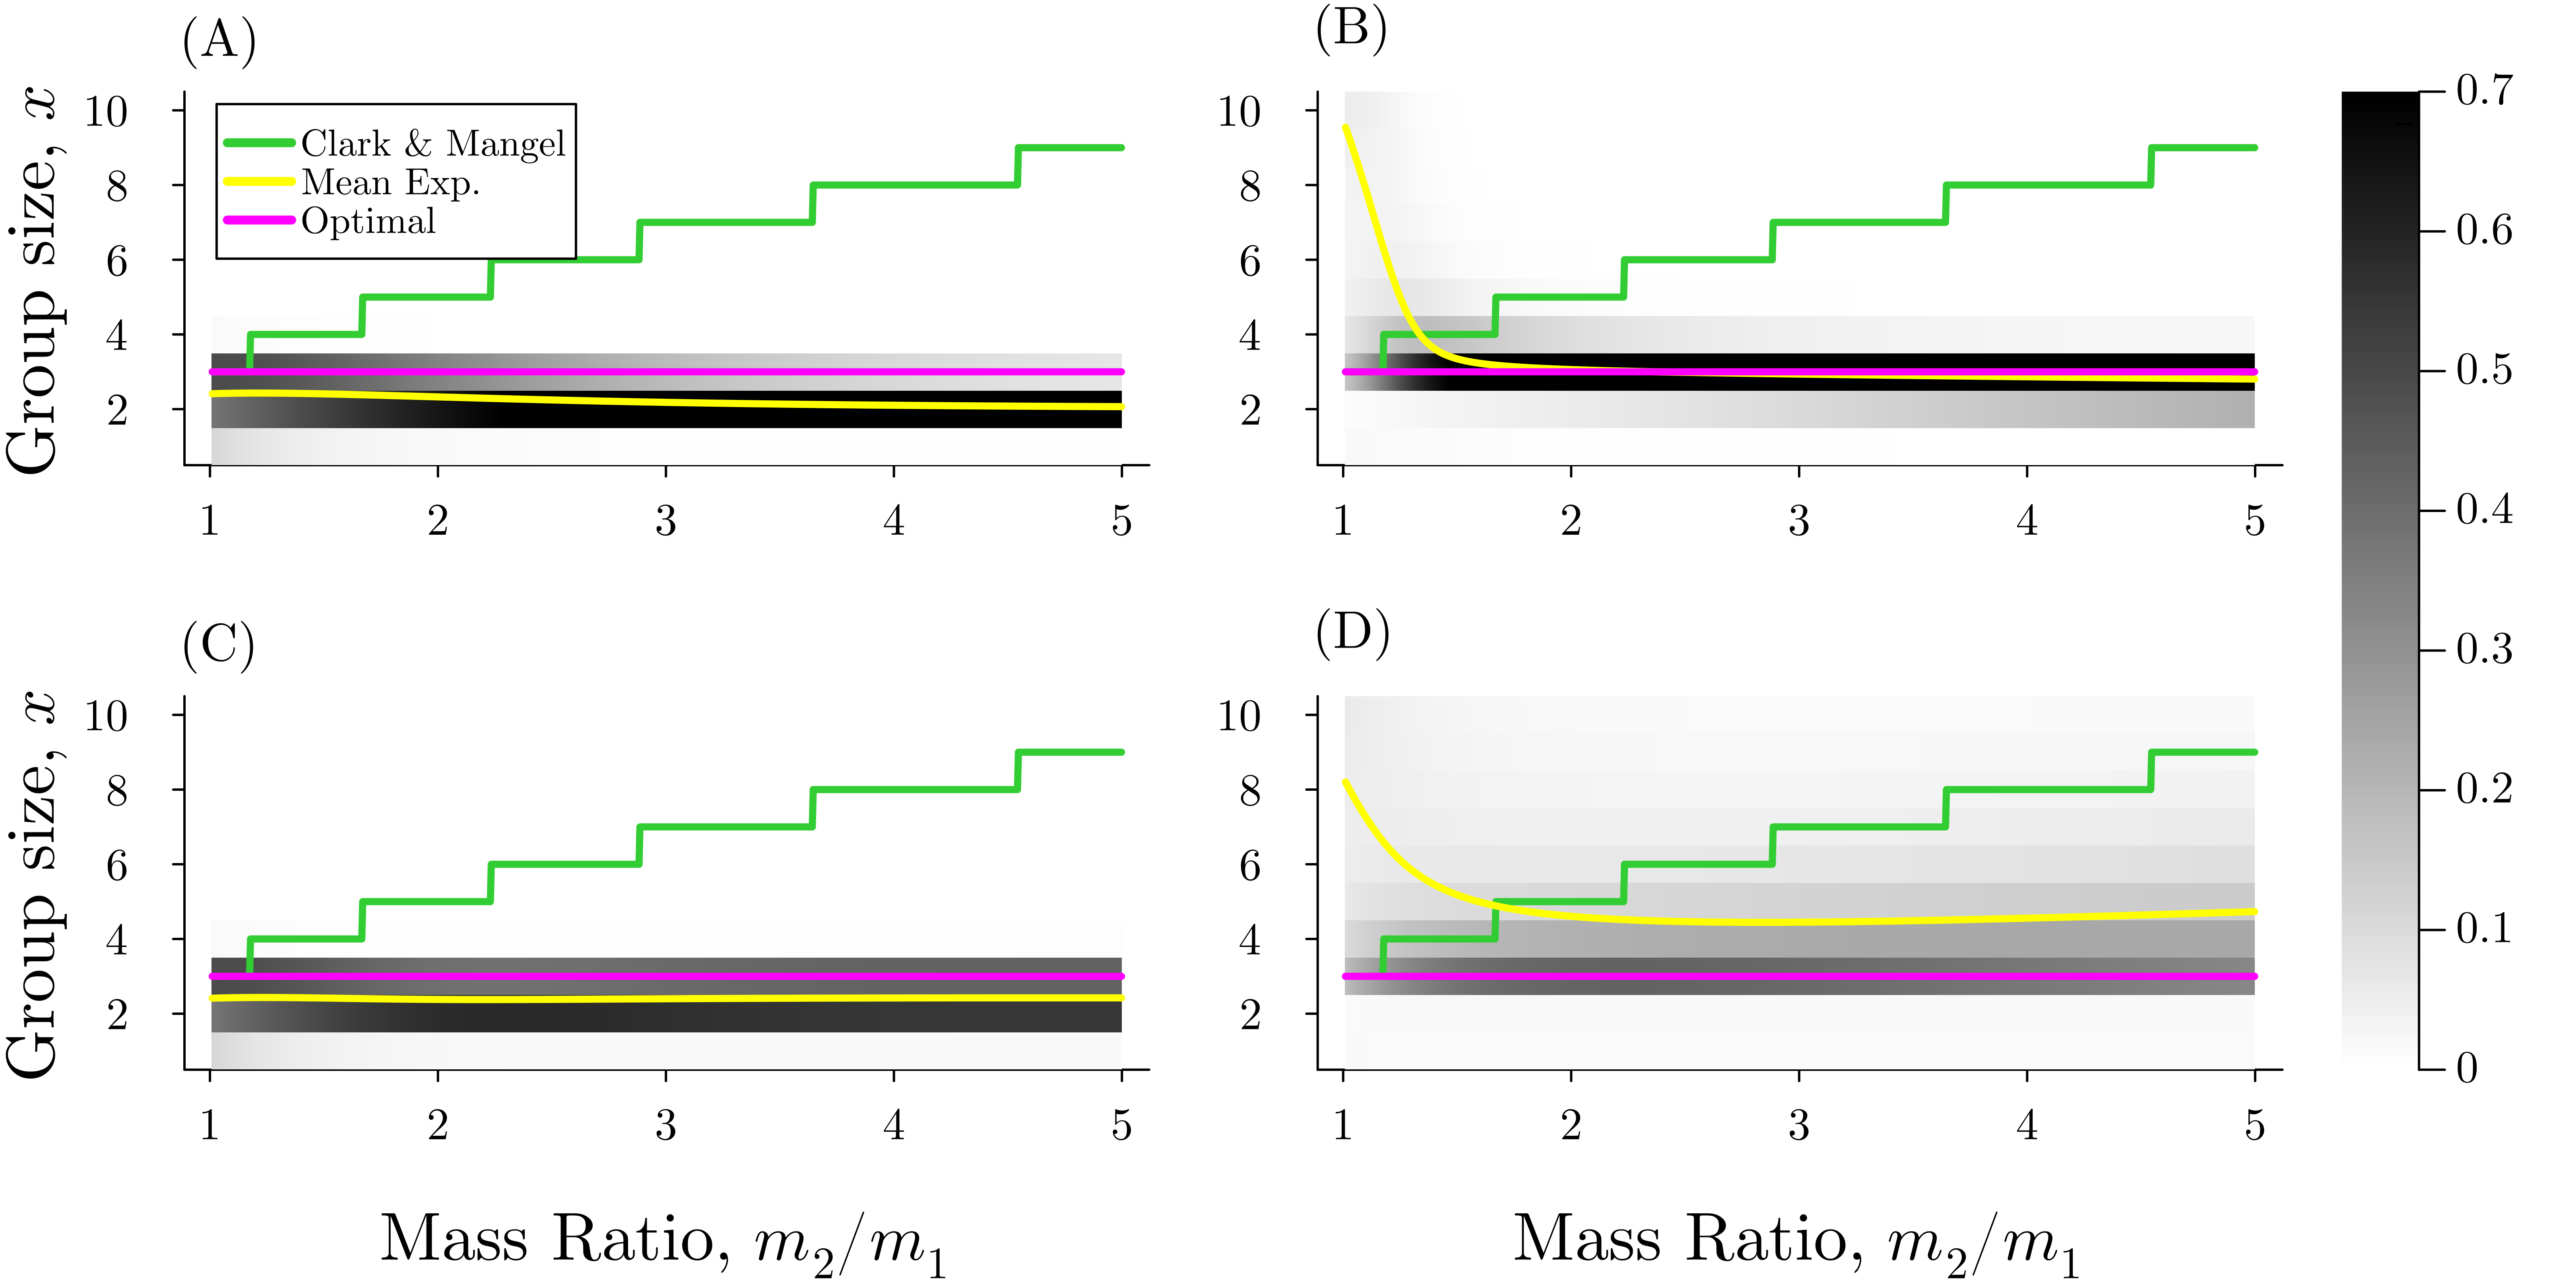

GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT


In [29]:
p_full

In [ ]:
using Measures

clims = (0.0, 0.7)

# remove annotations of all panels except first one
for hm in [hm6, hm7, hm8]
    hm.subplots[1][:annotations] = []
end

p1 = plot( 
    plot(hm5; xlab = "",legend=false),
    plot(hm6; xlab = "", ylab = "", right_margin = 5mm, legend=false),
    plot(hm7; legend=false), 
    plot(hm8; ylab = "", legend = false); 
    clims = clims, colorbar = false,
    title = ["(A)\n" "(B)" "(C)\n" "(D)"], titlelocation = :left,
    titlefonthalign = :left,
    ylims = (0.5,10.5),
    legendfontsize = 12,
    tick_direction = :out
    )
p_cb = heatmap(fill(NaN, 2, 2); clims, c = cgrad([:white, :black], 256), colorbar=:right,
               framestyle=:none, ticks=false)
#plot!(hm1; legend = true)
p_full2 = plot(
    p1, p_cb; layout = grid(1, 2, widths=[0.94, 0.06]), size=(1080, 540), 
    bottom_margin = 8mm, left_margin = 5mm, legendfontsize=10
    )

savefig(p_full2, bif_fig_path * "4heatmaps_ratio_orig_pairing_leaving_separate_grouplevel.pdf")



In [ ]:
using Measures
hm4.subplots[1][:annotations] = []
clims = (0.0, 0.7)

# remove annotations of all panels except first one

p1 = plot( 
    plot(hm7; legend=false),
    plot(hm4; ylab = "", right_margin = 5mm, legend=false);
    clims = clims, colorbar = false,
    title = ["(A)\n" "(B)"], titlelocation = :left,
    titlefonthalign = :left,
    ylims = (0.5,10.5),
    tick_direction = :out
    )
p_cb = heatmap(fill(NaN, 1, 2); 
clims, c = cgrad([:white, :black], 256), colorbar=:right,
               framestyle=:none, ticks=false)
#plot!(hm1; legend = true)
p_full3 = plot(
    p1, p_cb; layout = grid(1, 2, widths=[0.94, 0.06]), size=(1080, 540), 
    bottom_margin = 8mm, left_margin = 5mm, legendfontsize=10
    )

savefig(p_full3, bif_fig_path * "2heatmaps_ratio_orig_leaving_both_grouplevel.pdf")



In [ ]:
display(p_full2)


In [ ]:
p_full